<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
unit: Unit 1 — Foundations of Machine Learning for Bioinformatics
submodule: 1.2 Data Preprocessing & Feature Engineering
document_type: Practical Review Notebook
ai_tier: Full AI (Learning Aid)
---

# 👥 Classmate Age Distribution: Statistical Review & Scaling Bridge

---
<img src="./assets/outlier_scalers_infographic.jpg" alt="Outliers & Feature Scaling: The Statistical Tug-of-War" width="100%"/>


## Context & Purpose
In Day 4, you collected an analog dataset: the ages of your classmates in the M.Sc. Bioinformatics cohort.

The goals of this review are to:
1. **Inspect Distribution Shape:** Plot the age distribution to see whether real-world biological and human cohort data follows a bell curve (normal distribution) or exhibits skewness and outliers.
2. **Contrast Summary Metrics:** Compare parametric statistics ($\mu$ mean, $\sigma$ standard deviation) against non-parametric statistics (median, interquartile range IQR).
3. **Bridge Directly to Feature Scaling:** Understand why distribution shape and outliers dictate whether we apply `StandardScaler`, `MinMaxScaler`, or `RobustScaler`.



## 1. Classmate Cohort Age Dataset

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Representative sample of an M.Sc. Bioinformatics cohort (N = 28 students)
# Most students are recent graduates (21-24), with a few returning scholars (28, 33)
classmate_ages = np.array([
    21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23,
    24, 24, 24, 24, 24, 25, 25, 25, 26, 26, 27, 28,
])
# classmate_ages = np.random.exponential(scale=2.0, size=1000)
# classmate_ages = 1 - classmate_ages

df_ages = pd.DataFrame({"Age": classmate_ages})
print(f"Cohort size: {len(df_ages)} students")
print(f"Raw ages: {list(df_ages['Age'])}")

Cohort size: 26 students
Raw ages: [21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 25, 25, 25, 26, 26, 27, 28]


## 2. Statistical Analysis: Parametric vs. Non-Parametric Metrics

Let us calculate the statistical profile of our cohort:
* **Parametric measures:** Mean ($\mu$) and Standard Deviation ($\sigma$) assume data is symmetrically spread around the center. Outliers heavily pull the mean.
* **Non-parametric measures:** Median ($Q_2$) and Interquartile Range ($\text{IQR} = Q_3 - Q_1$) rely on ranks, ignoring extreme tail values.

In [ ]:
# Affected by outliers
mean_age = df_ages['Age'].mean()
std_age = df_ages['Age'].std()

# Affected by outliers
median_age = df_ages['Age'].median()
q1 = df_ages['Age'].quantile(0.25)
q3 = df_ages['Age'].quantile(0.75)
iqr = q3 - q1
skewness = df_ages['Age'].skew()

print("=== Parametric Statistics ===")
print(f"Mean (μ):               {mean_age:.2f} years")
print(f"Standard Deviation (σ): {std_age:.2f} years")

print("\n=== Non-Parametric Statistics ===")
print(f"Median (Q2):            {median_age:.1f} years")
print(f"25th Percentile (Q1):   {q1:.1f} years")
print(f"75th Percentile (Q3):   {q3:.1f} years")
print(f"IQR (Q3 - Q1):          {iqr:.1f} years")

print(f"\nDistribution Skewness:  {skewness:.2f} (Positive = Right-skewed tail)")

=== Parametric Statistics ===
Mean (μ):               24.32 years
Standard Deviation (σ): 3.03 years

=== Non-Parametric Statistics ===
Median (Q2):            23.5 years
25th Percentile (Q1):   22.8 years
75th Percentile (Q3):   25.0 years
IQR (Q3 - Q1):          2.2 years

Distribution Skewness:  2.07 (Positive = Right-skewed tail)


## 3. Visualizing Cohort Distribution & Outlier Impact

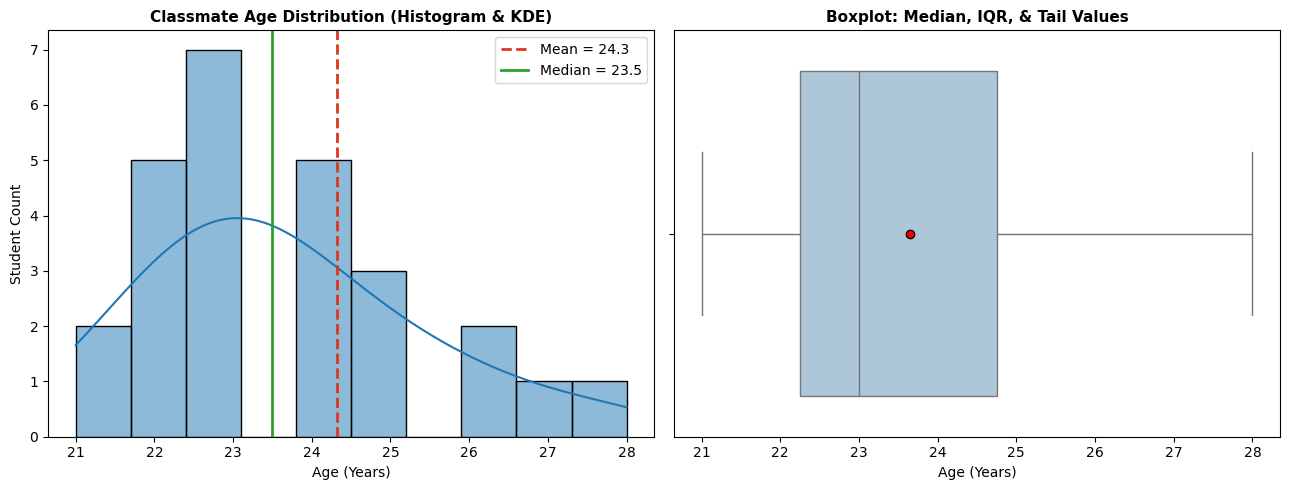

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Histogram + KDE curve
sns.histplot(df_ages['Age'], kde=True, bins=10, ax=axes[0], color='#1f77b4', edgecolor='black')
axes[0].axvline(mean_age, color='#d9381e', linestyle='--', lw=2, label=f'Mean = {mean_age:.1f}')
axes[0].axvline(median_age, color='#2ca02c', linestyle='-', lw=2, label=f'Median = {median_age:.1f}')
axes[0].set_title('Classmate Age Distribution (Histogram & KDE)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Student Count')
axes[0].legend(frameon=True)

# Panel 2: Boxplot highlighting the IQR and outliers
sns.boxplot(x=df_ages['Age'], ax=axes[1], color='#a6c8e0', showmeans=True, 
            meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
axes[1].set_title('Boxplot: Median, IQR, & Tail Values', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Age (Years)')

plt.tight_layout()
plt.show()